In [29]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy.interpolate import splev, splrep, interp1d
import scipy.optimize as opt
from scipy.signal import find_peaks, medfilt

# Gaussian process for curve fitting
#import george
#from george.kernels import ExpSquaredKernel

import glob

from pdastro import *


In [31]:
from LC_utility import *

In [9]:
from regions import Regions

regions = Regions.read("ec0915_good2pos.reg", format="ds9")


In [27]:
def get_imgarr(fitsfile, idx=0, return_header=False):
    """get image array from fits
    Parameters:
        fitsfile: FITS file
        idx: hdul index in FITS
        return_header: boolean, return FITS header
    """
    from astropy.io import fits
    hdul = fits.open(fitsfile)
    item = hdul[idx]
    if item.is_image:
        header = item.header
        # invert y to be same as jpg
        #imgarr = item.data[::-1, :] 
        imgarr = item.data
        hdul.close()
        if return_header:
            return imgarr, header
        else:
            return imgarr
    else:
        print('not image file')


In [56]:

url_54_i = "https://stsci-transients.stsci.edu/\
eta/etalc/results/rod_test/good2_i/\
ec0915/54/ec0915a54_good2pos_i_tmpl523435.html"
table_a54_i = get_LCtable(url_54_i)

url_57_i = "https://stsci-transients.stsci.edu/\
eta/etalc/results/rod_test/good2_i/\
ec0915/57/ec0915a57_good2pos_i_tmpl523435.html"
table_a57_i = get_LCtable(url_57_i)





In [103]:
table_a57_i.to_csv('good2/LCref_a57_i.csv', index=False)



In [124]:
lc_list1_i = get_LCdata(table_a57_i, group=0, )


In [125]:
lc_list1_i.to_csv('good2/LCtable1_i.csv', index=False)


In [126]:
#lc_df1 = readin_LCdf('LC_tables/data/LCtable1_i.csv')

lc_df1 = readin_LCdf('good2/LCtable1_i.csv')


In [127]:
lc_df1.t

,ID,x,y,bsize,mjd,zpt,fluxADU,flux_err,X2norm,Npix,...,CONVOL00,PHOTNORM,KSUM00,FSIG00,FSCAT00,FWHM,M5SIGMA,SKYADU,muJyas2,muJyas2_err
0,0,2069,2290,3,56341.211110,30.151,2.61,5.02,1.04,9,...,TEMPLATE,t,1.0856,1.384,0.109,3.834,23.216,1025.0,0.11320,0.2175
1,0,2069,2290,3,56341.216066,30.151,6.83,4.74,0.42,9,...,TEMPLATE,t,1.0883,1.335,0.080,4.222,23.151,1006.0,0.29610,0.2053
2,0,2069,2290,3,56341.219000,30.151,-3.06,4.87,1.15,9,...,TEMPLATE,t,1.1000,1.419,0.123,3.981,23.186,1023.0,-0.13280,0.2110
3,0,2069,2290,3,56343.220957,30.151,-1.11,5.62,0.23,9,...,TEMPLATE,t,1.1045,1.460,0.141,4.085,23.090,1220.0,-0.04828,0.2435
4,0,2069,2290,3,56343.222439,30.151,5.51,5.28,1.20,9,...,TEMPLATE,t,1.1069,1.426,0.125,4.061,23.070,1233.0,0.23900,0.2290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,14,2059,2285,3,61136.291582,30.151,68.77,8.91,2.22,9,...,TEMPLATE,t,1.0120,1.079,0.051,5.276,22.231,2618.0,2.98100,0.3865
6146,14,2059,2285,3,61137.222243,30.151,67.91,7.30,0.45,9,...,TEMPLATE,t,1.0208,1.117,0.091,3.594,22.773,2029.0,2.94400,0.3165
6147,14,2059,2285,3,61138.026535,30.151,70.66,7.08,1.13,9,...,TEMPLATE,t,1.0286,1.095,0.067,4.956,22.506,1581.0,3.06300,0.3071
6148,14,2059,2285,3,61139.226119,30.151,63.97,7.09,0.87,9,...,TEMPLATE,t,1.0154,1.204,0.136,3.126,23.071,1400.0,2.77300,0.3074


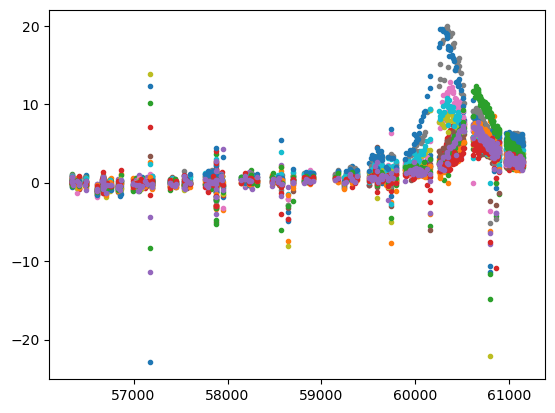

In [181]:
for i in range(15):
    plt.plot(lc_list1_i[lc_list1_i['ID']==i].mjd, lc_list1_i[lc_list1_i['ID']==i].muJyas2, '.')
    

(60790.0, 60800.0)

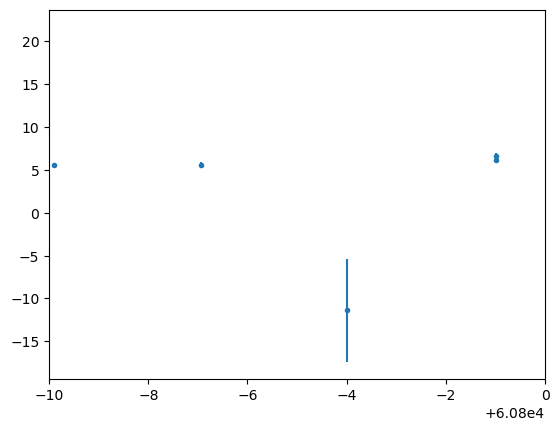

In [98]:
i = 0
x = lc_list1_i[lc_list1_i['ID']==i].mjd
y = lc_list1_i[lc_list1_i['ID']==i].muJyas2
yerr = lc_list1_i[lc_list1_i['ID']==i].muJyas2_err

plt.errorbar(x,  y,  yerr, fmt='.')

plt.xlim([60790, 60800])

In [11]:
ra = [reg.center.ra.deg for reg in regions]

dec = [reg.center.dec.deg for reg in regions]

In [115]:
#lcpath = "https://stsci-transients.stsci.edu/eta/etalc/results/rod_test/good2_i/ec0915/54/ec0915a54_good2pos_i_tmpl523435_ID0_lc.txt"
#df_lc = pd.read_csv(lcpath, sep=' ')


In [128]:
bad_expnums_a54i = pd.read_csv('txt_files/a54i_badims.csv')['a54'].values
bad_expnums_a57i = pd.read_csv('txt_files/a57i_badims.csv')['a57'].values


In [129]:
f_lim = 20.0              # upper limit of flux (muJyas2)
ferr_lim = 1.0            # upper limit of flux error (muJyas2_err)

# ### The working indices for fitting process -- run before the rest
bin_sz = None
flag_inds(lc_df1, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a57i, bin_size=bin_sz)


'Updated LC dataframe -- flagged working indices'

In [132]:
lc_df1.t.columns

Index(['ID', 'x', 'y', 'bsize', 'mjd', 'zpt', 'fluxADU', 'flux_err', 'X2norm',
       'Npix', 'Nmask', 'Jyas2', 'Jyas2_err', 'SB', 'SB_err', 'fitsfile',
       'skip', 'imID', 'filter', 'CONVOL00', 'PHOTNORM', 'KSUM00', 'FSIG00',
       'FSCAT00', 'FWHM', 'M5SIGMA', 'SKYADU', 'muJyas2', 'muJyas2_err',
       'g_ixs_flag'],
      dtype='object')

In [133]:
## segment 1
templ_ID1 = 2
fit_parms1 = fit_LCs(lc_df1, templ_ID=templ_ID1, metric=1e4)


In [134]:
templ_ID1

2

0


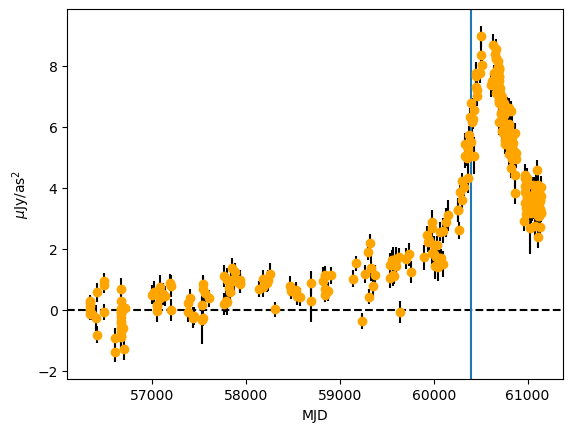

1


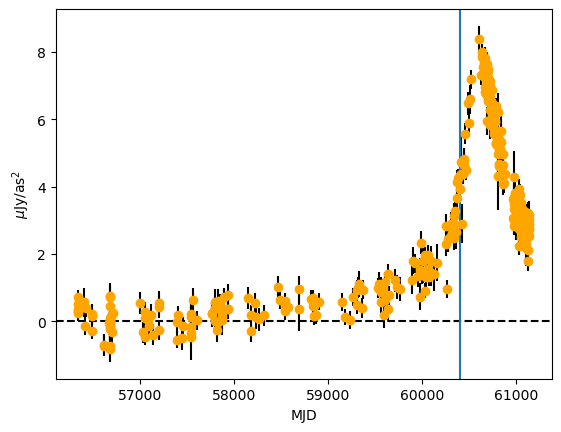

2


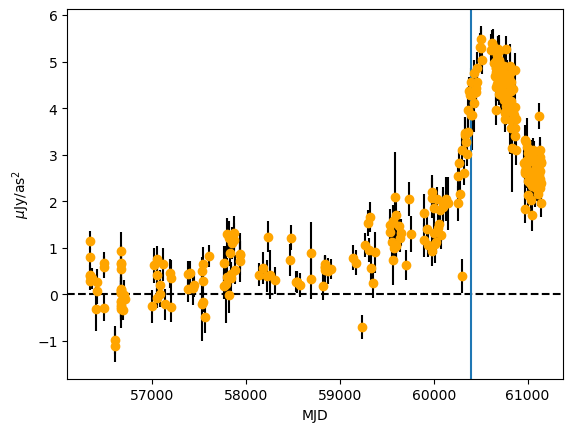

3


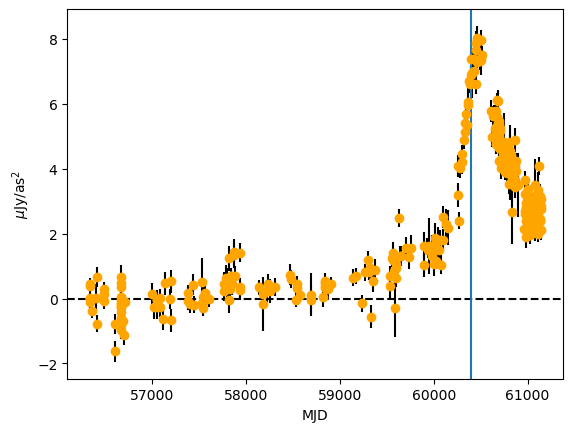

4


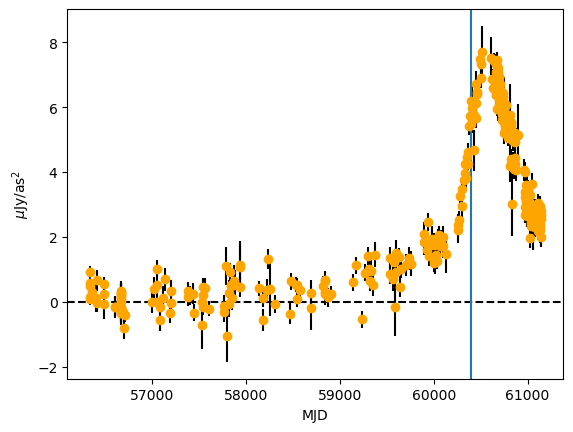

5


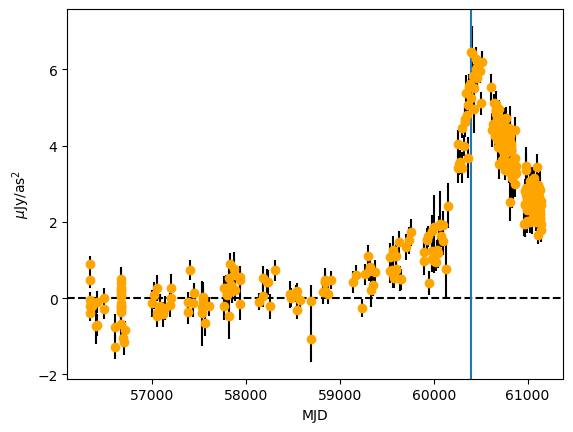

6


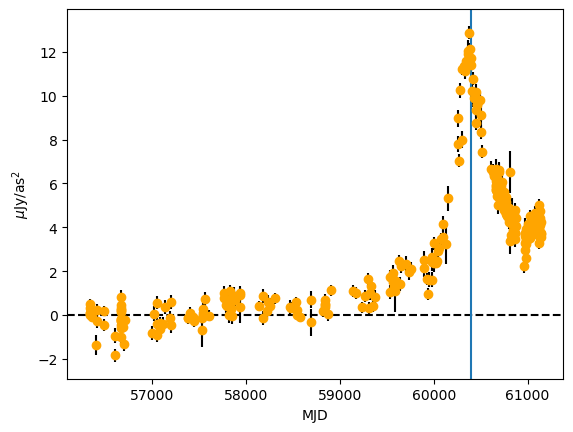

7


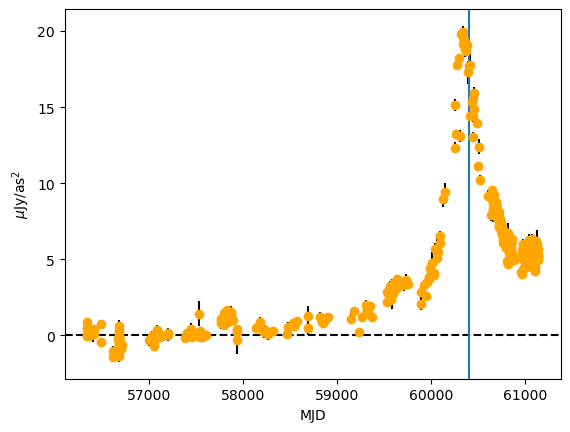

8


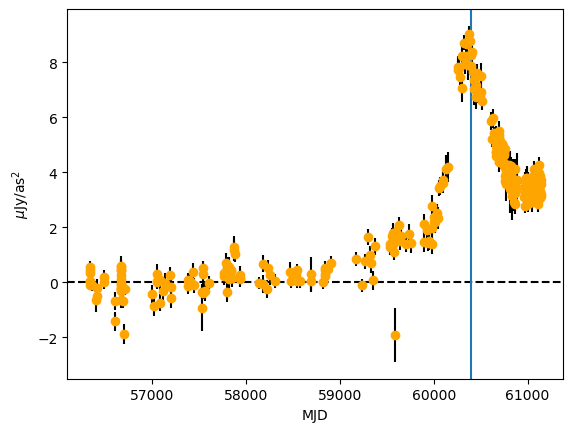

9


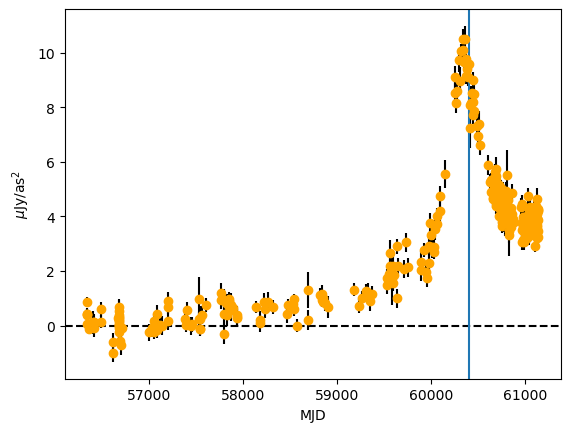

10


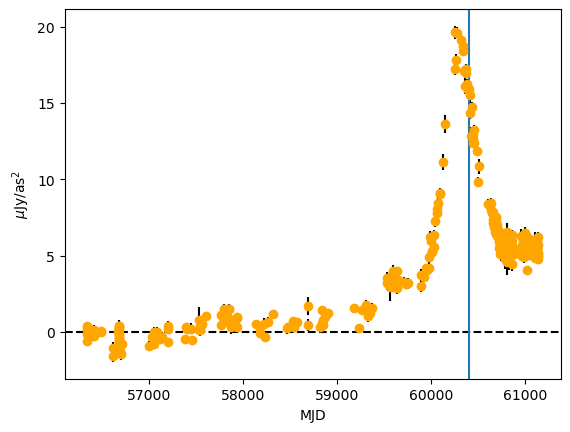

11


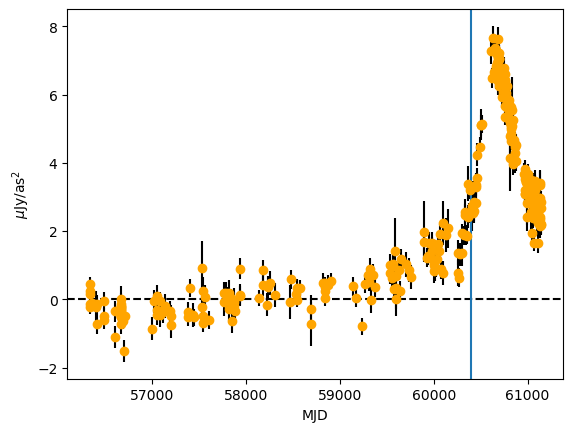

12


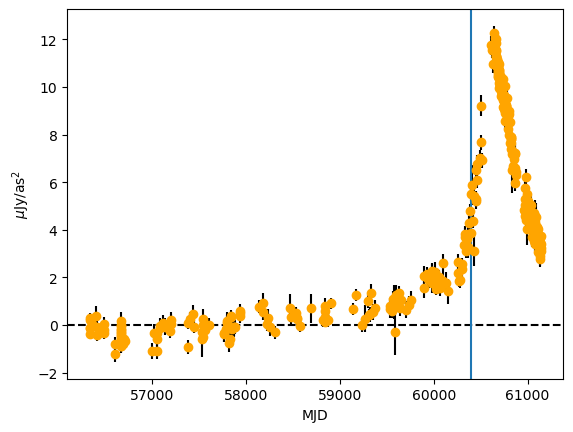

13


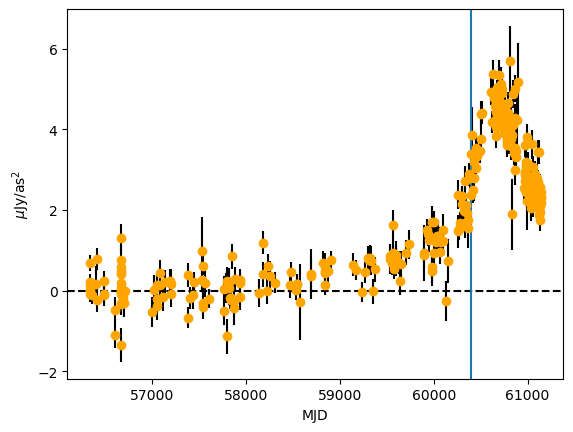

14


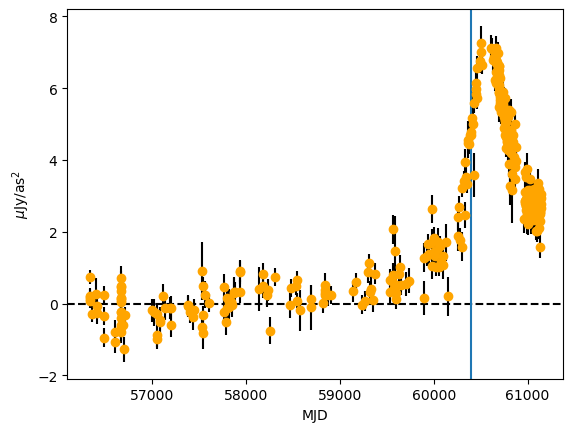

'Done plotting'

In [136]:
plot_lcs(lc_df1, plt_xl=60400)

'Plotting LC fits'

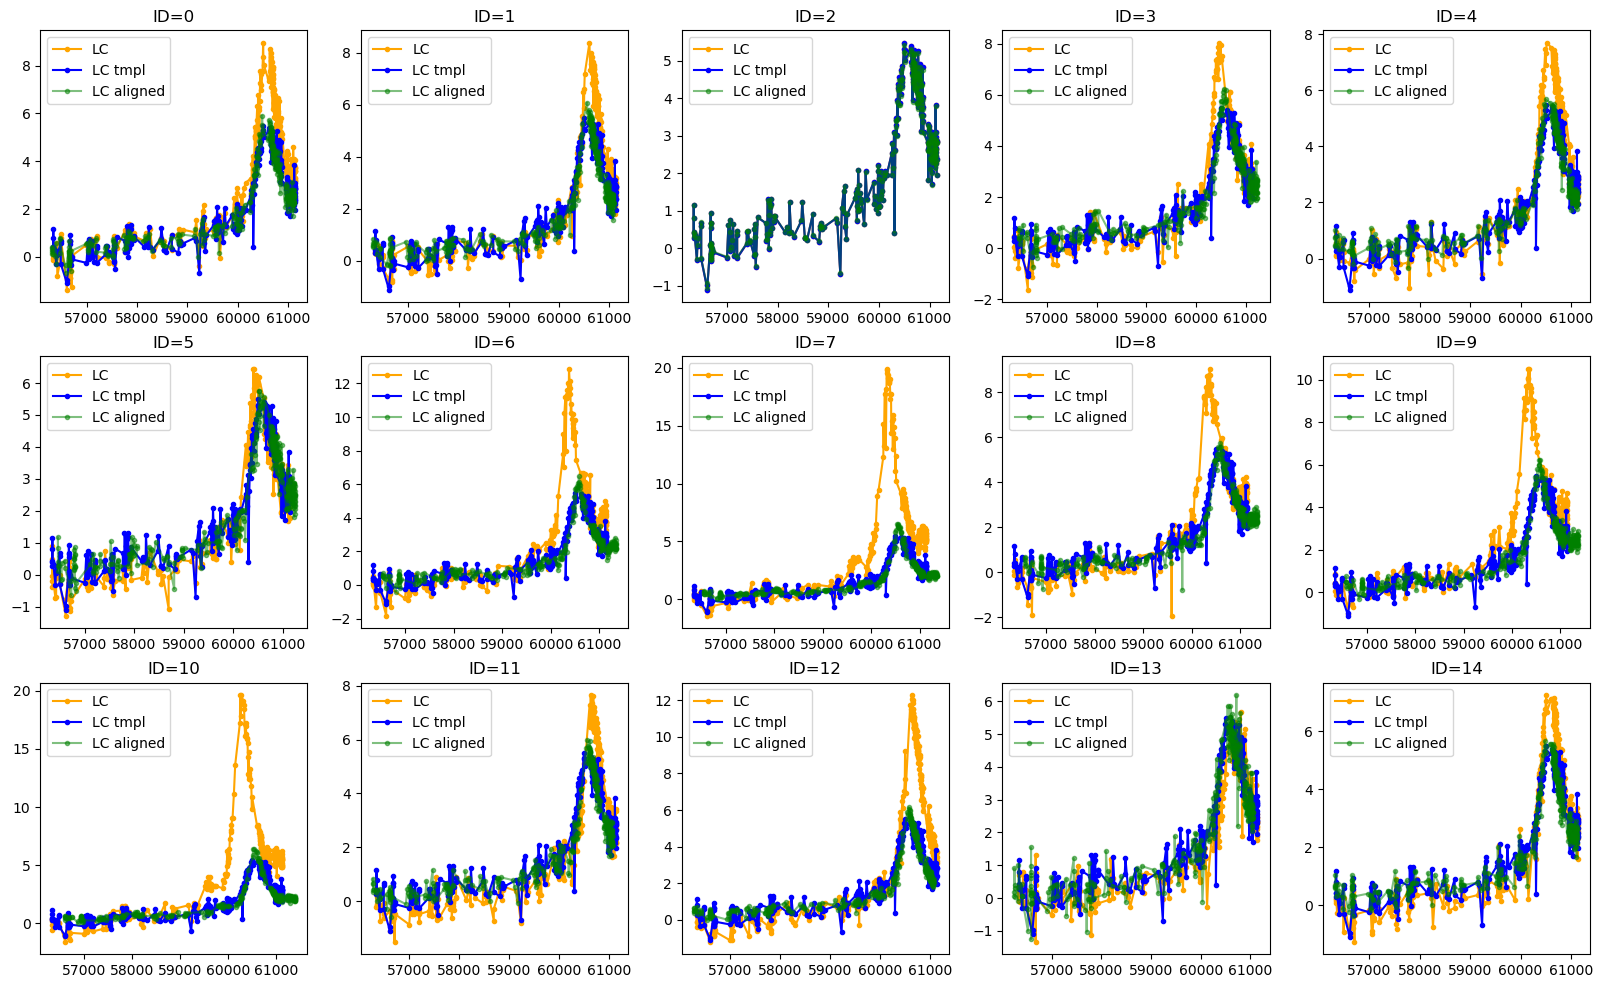

In [163]:
df = lc_df1
fit_ps = fit_parms1
t_ID = templ_ID1
plot_LCfits(df,fit_ps, templ_ID=t_ID)

images

In [170]:
fits57_diff_523730 = glob.glob("../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/*523730_ooi_g_*.fits")
fits57_diff_523730.sort()
fits57_diff_523730

['../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.121124.155038_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.121124.155039_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178882_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178883_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178884_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130506.204626_ooi_g_v1_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130714.218754_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130715.219198_ooi_g_N26_160306.523730_ooi_g_v1_N26.diff.fits',
 '../../Research/Eta_

In [169]:
fits57_diff_523435 = glob.glob("../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/*523435_ooi_i_*.fits")
fits57_diff_523435.sort()
fits57_diff_523435

['../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178843_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178844_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130218.178845_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130220.179486_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130220.179487_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130309.184934_ooi_i_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130420.199841_ooi_i_v1_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/57/ec0915.130420.199842_ooi_i_v1_N26_160305.523435_ooi_i_v1_N26.diff.fits',
 '../../Research/E

In [165]:
fits54_diff_523435 = glob.glob("../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/*523435_ooi_i_*.fits")
fits54_diff_523435.sort()
fits54_diff_523435

['../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130218.178843_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130218.178844_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130218.178845_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130220.179486_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130220.179487_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130309.184934_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130420.199841_ooi_i_v1_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130420.199842_ooi_i_v1_N22_160305.523435_ooi_i_v1_N22.diff.fits',
 '../../Research/E

In [138]:
len(fits54_diff_523435)

215

In [141]:
bad_expnums_a54i.sort()

In [142]:
bad_expnums_a54i

array([ 443409,  443411,  443453,  443455,  646109,  927464, 1051159,
       1053346, 1058364, 1062143, 1063439, 1064950, 1068343, 1070415,
       1072685, 1073328, 1074494, 1075209, 1085354, 1086705, 1093189,
       1102551, 1105609, 1111159, 1115459, 1116931, 1118055, 1149500,
       1150875, 1156439, 1164230, 1169866, 1170748, 1173624, 1177499,
       1180038, 1180646, 1189511, 1191555, 1198564, 1199865, 1201908,
       1208151, 1209986, 1217856, 1224837, 1227844, 1253249, 1256691,
       1260835, 1262436, 1267287, 1271302, 1271733, 1272872, 1273642,
       1275067, 1278337, 1278996, 1280320, 1282947, 1284486, 1284956,
       1288610, 1289520, 1293143, 1294667, 1298802, 1299309, 1299887,
       1300853, 1301831, 1312453, 1314559, 1335989, 1340098, 1341549,
       1343222, 1345437, 1347662, 1348311, 1348704, 1349061, 1349680,
       1349685, 1349693, 1349701, 1350177, 1350826, 1351624, 1355110,
       1355115, 1355123, 1355131, 1355139, 1355485, 1356779, 1357397,
       1357797, 1357

In [144]:
st = '../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.130218.178843_ooi_i_N22_160305.523435_ooi_i_v1_N22.diff.fits'


In [156]:
i

'../../Research/Eta_Car/ec0915_data/ec0915_tmpl/54/ec0915.240113.1267287_ooi_i_v1_N22_160305.523435_ooi_i_v1_N22.diff.fits'

In [157]:
fits54_diff_523435_bad = []
for i in fits54_diff_523435:
    for j in bad_expnums_a54i:
        if str(j) in i:
            fits54_diff_523435_bad.append(i)

fits54_diff_523435_good = [x for x in fits54_diff_523435 if x not in fits54_diff_523435_bad]


In [167]:
len(fits54_diff_523435_good)

163

In [162]:
len(fits54_diff_523435_good)

163